In [1]:
from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.test_functions import Ishigami
import numpy as np

In [2]:
from SALib.sample.sobol import sample as sobol_sample

In [3]:
problem = {
    'num_vars': 3,
    'names': ['x1', 'x2', 'x3'],
    'bounds': [[-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359]]
}

In [4]:
problem

{'num_vars': 3,
 'names': ['x1', 'x2', 'x3'],
 'bounds': [[-3.14159265359, 3.14159265359],
  [-3.14159265359, 3.14159265359],
  [-3.14159265359, 3.14159265359]]}

In [5]:
param_values = sobol_sample(problem, 1024, calc_second_order=False)
param_values

array([[-3.0168525 , -1.641595  , -1.26239434],
       [-0.23992464, -1.641595  , -1.26239434],
       [-3.0168525 ,  1.3886505 , -1.26239434],
       ...,
       [-3.01219994,  0.72890746,  1.30490874],
       [-3.01219994,  1.30969595, -2.13456713],
       [-1.51179442,  0.72890746, -2.13456713]], shape=(5120, 3))

In [6]:
Y = Ishigami.evaluate(param_values)

In [7]:
type(Y)

numpy.ndarray

In [8]:
Y

array([6.80895651, 6.66699156, 6.6143024 , ..., 2.93896129, 6.13662282,
       0.03470153], shape=(5120,))

In [11]:
Si = sobol.analyze(problem, Y, calc_second_order=False)

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [12]:
Si

{'S1': array([3.19277287e-01, 4.46554021e-01, 4.42249634e-05]),
 'S1_conf': array([0.06222339, 0.05469947, 0.06636238]),
 'ST': array([0.56740143, 0.45073644, 0.24799975]),
 'ST_conf': array([0.08945824, 0.04041182, 0.02622822])}

In [14]:
sum(Si["S1"])

np.float64(0.7658755329719318)

In [20]:
total_Si, first_Si, second_Si = Si.to_df()

In [21]:
first_Si

,S1,S1_conf
x1,0.278194,0.048981
x2,0.433989,0.049668
x3,-0.002814,0.054039


In [23]:
sum(first_Si["S1"])

0.7093692796609762

In [22]:
sum(first_Si["S1"]) + sum(second_Si["S2"])

1.0633367551047261

In [17]:
second_Si

,S2,S2_conf
"(x1, x2)",-0.008769,0.075912
"(x1, x3)",0.237234,0.098174
"(x2, x3)",-0.003026,0.059183


In [18]:
sum(second_Si["S2"])

0.22543912989446896

In [19]:
s2 = Si["S2"]
np.nansum(s2, axis=1)

array([ 0.228465  , -0.00302587,  0.        ])

In [31]:
s2_mat = Si["S2"]
s2_mat

array([[        nan,  0.00925429,  0.23817211],
       [        nan,         nan, -0.0048877 ],
       [        nan,         nan,         nan]])

In [32]:
np.nansum(s2_mat, axis=1)

array([ 0.2474264, -0.0048877,  0.       ])

In [33]:
np.nansum(np.triu(s2_mat, k=1))

np.float64(0.2425386979700055)

In [15]:
total_Si

,ST,ST_conf
x1,0.555860,0.070825
x2,0.441898,0.042353
x3,0.244675,0.026925


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

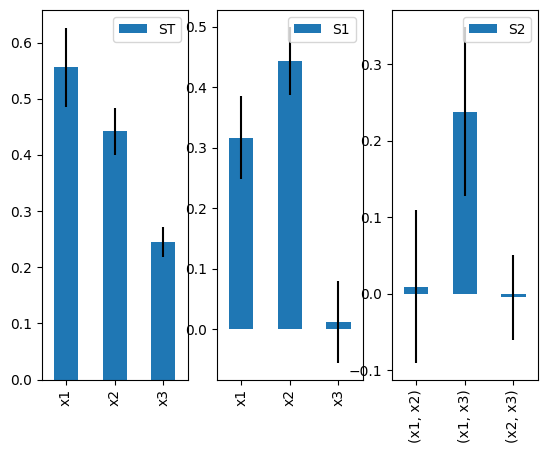

In [21]:
Si.plot()